In [1]:
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [2]:
years = range(2025, 2036)
path = Path.cwd().parent / 'results' / 'networks' 

#### Transport

In [3]:
ns = {
    year: pypsa.Network(path / f'base_s_50__168H-T-H-B-I-A-dist1_{year}.nc')
    for year in years
}
n = ns[2025]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2026.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2027.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2028.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2029.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, store

In [14]:
n[2025].loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

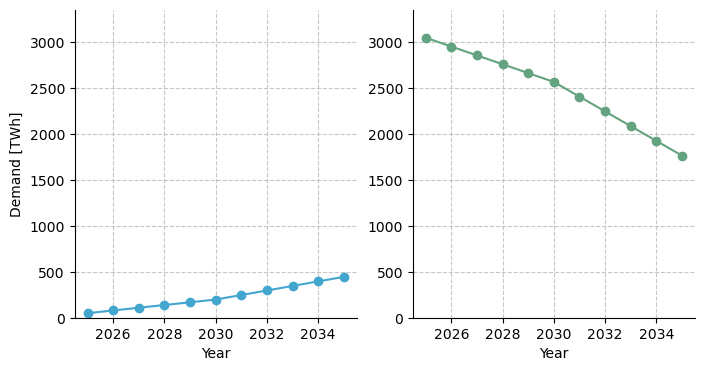

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

ev_load = list()
ice_load = list()

w = n.snapshot_weightings.generators.iloc[0]

for year in years:

    evs = ns[year].loads.index[ns[year].loads.carrier == 'land transport EV']
    ices = ns[year].loads.index[ns[year].loads.carrier == 'land transport oil']

    ev_load.append(ns[year].loads_t.p_set.loc[:, evs].sum().sum() * w * 1e-6)
    ice_load.append(ns[year].loads_t.p_set.loc[:, ices].sum().sum() * w * 1e-6)

axs[0].plot(years, ev_load, marker='o', color=np.random.rand(3,))
axs[1].plot(years, ice_load, marker='o', color=np.random.rand(3,))

axs[0].set_ylabel('Demand [TWh]')


for ax in axs:
    ax.set_ylim(0, max(max(ev_load), max(ice_load)) * 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Year')


plt.show()

In [9]:
ns[2026].statistics.energy_balance().index.get_level_values(2).unique()

Index(['AC', 'Battery Storage', 'co2 sequestered', 'home battery',
       'non-sequestered HVC', 'biogas', 'co2', 'coal', 'gas', 'lignite',
       'oil primary', 'rural heat', 'solid biomass',
       'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'Hydrogen Storage', 'NH3', 'low voltage',
       'agriculture machinery oil', 'coal for industry', 'gas for industry',
       'industry methanol', 'kerosene for aviation', 'EV battery',
       'land transport oil', 'naphtha for industry', 'process emissions',
       'shipping methanol', 'shipping oil', 'solid biomass for industry',
       'co2 stored', 'oil', 'methanol', 'uranium'],
      dtype='object', name='bus_carrier')

In [30]:
idx = pd.IndexSlice

heating_carriers = [
    'urban decentral heat',
    'urban central heat',
    'rural heat',
]

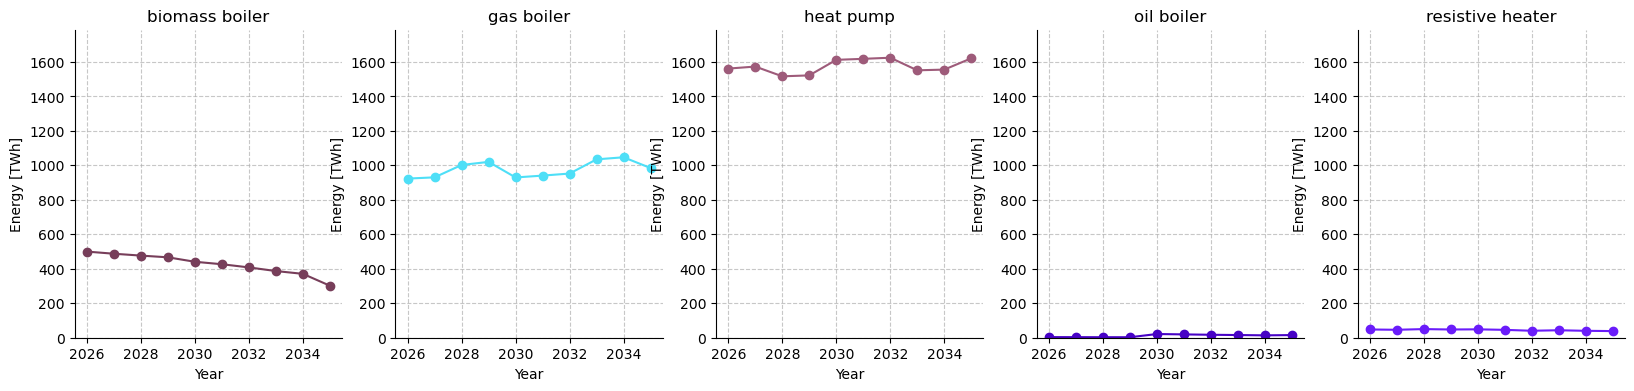

In [56]:
indicators = ['gas boiler', 'biomass boiler', 'resistive heater', 'heat pump', 'oil boiler']

def clean_carrier(carrier):
    if len(matches := [ind for ind in indicators if ind in carrier]) > 0:
        return matches[0]
    else:
        return 'other'


fig, axs = plt.subplots(1, len(indicators), figsize=(len(indicators) * 4, 4))

data = []

for year in years:
    try:
        eb = ns[year].statistics.energy_balance().loc[
            idx[:, :, heating_carriers]
            ].sort_values()
    except KeyError:
        continue

    grouper = {
        carrier: clean_carrier(carrier)
        for carrier in eb.index.get_level_values(1)
    }

    eb.index = eb.index.get_level_values(1)
    eb = eb.groupby(grouper).sum().drop('other').mul(1e-6)

    data.append(eb.rename(year))

data = pd.concat([d.to_frame() for d in data], axis=1)

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs[i]

    row.plot(ax=ax, marker='o', color=np.random.rand(3,))
    ax.set_title(name)
    ax.set_ylabel('Energy [TWh]')


for ax in axs:
    ax.set_ylim(0, data.max().max() * 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Year')

plt.show()


In [57]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [64]:
industry_loads = [
    'gas for industry',
    'H2 for industry',
    'naphtha for industry',
    'coal for industry',
    'low-temperature heat for industry',
    'industry electricity',
    'solid biomass for industry',
    'industry methanol',
]

data = []

for year in years:

    year_loads = []

    for load in industry_loads:
        index = n.loads.index[n.loads.carrier == load]
        
        try:
            year_loads.append(ns[year].loads_t.p_set.loc[:, index].sum().sum() * w * 1e-6)
        except KeyError:
            year_loads.append(ns[year].loads.loc[index, 'p_set'].sum() * w * 1e-6 * len(n.snapshots))
    
    year_loads = pd.DataFrame({year: year_loads}, index=industry_loads)
    data.append(year_loads)

data = pd.concat(data, axis=1)

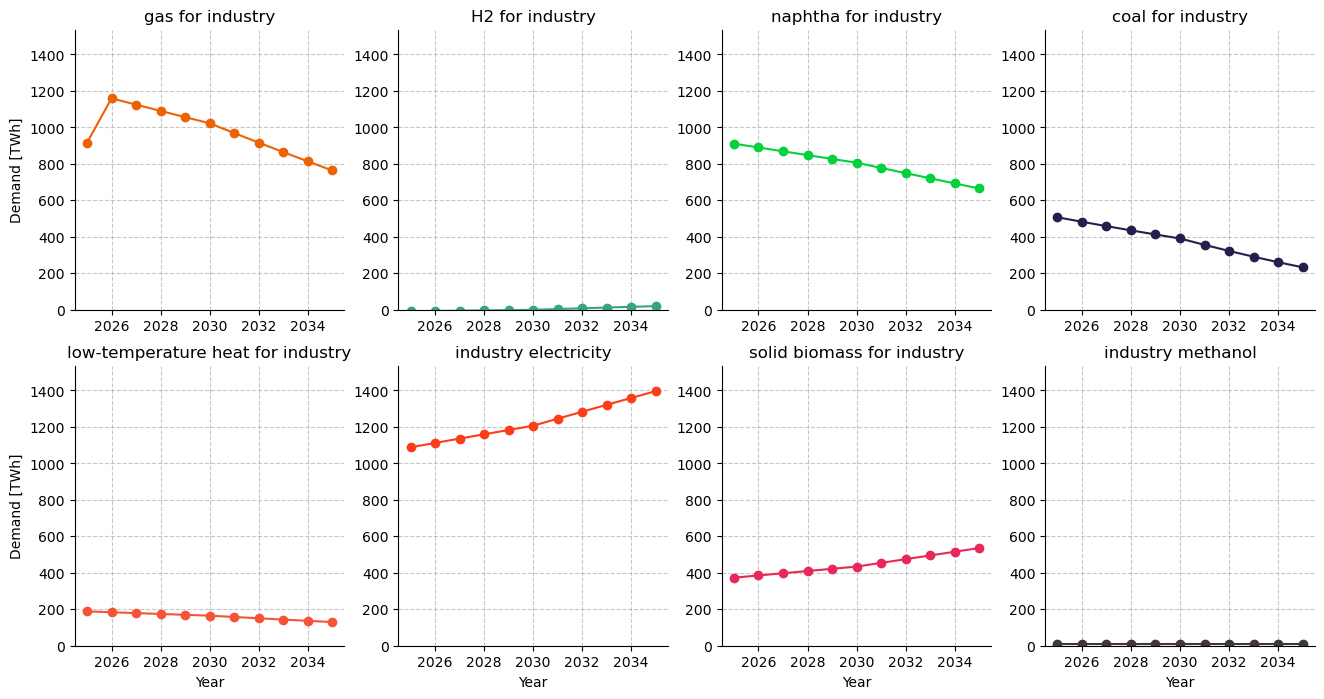

In [71]:
fig, axs = plt.subplots(2, len(industry_loads)//2, figsize=(len(industry_loads)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]

    row.plot(ax=ax, marker='o', color=np.random.rand(3,))
    ax.set_title(name)

for ax in axs.flatten():
    ax.set_ylim(0, data.max().max() * 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axs[1]:
    ax.set_xlabel('Year')

for ax in axs[:,0]:
    ax.set_ylabel('Demand [TWh]')


In [81]:
cs = n.statistics.optimal_capacity().index.get_level_values(1).unique()
[c for c in cs if 'umped' in c]

['Pumped Hydro Storage']

In [122]:
capacities = {
    'offwind': ['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)'],
    'onwind': ['Onshore Wind'],
    'solar': ['Solar', 'solar-hsat'],
    'hydro': ['Run of River', 'Reservoir & Dam'],
    'gas': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
    'coal': ['coal', 'lignite'],
    'nuclear': ['nuclear'],
    'battery': ['Battery Storage'],
    'PHS': ['Pumped Hydro Storage'],
    'electrolyser': ['H2 Electrolysis'],
}

In [123]:
'nuclear' in n.statistics.optimal_capacity().index.get_level_values(1).unique()

True

In [124]:
n.statistics.optimal_capacity().loc[idx[:, 'nuclear']]

component
Generator    105286.10000
Link         318877.60736
dtype: float64

In [125]:
data = []

for year in years:

    year_caps = []
    caps = ns[year].statistics.optimal_capacity()

    for name, carriers in capacities.items():
        
        if name in ['coal', 'gas', 'nuclear']:
            year_caps.append(caps.loc[idx['Link', carriers]].sum() * 1e-3)
        else:
            year_caps.append(caps.loc[idx[:, carriers]].sum() * 1e-3)

    year_caps = pd.DataFrame({year: year_caps}, index=capacities.keys())
    data.append(year_caps)

data = pd.concat(data, axis=1)
data


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
offwind,53.874729,55.473433,57.700552,58.995793,60.733587,62.070386,63.581700,66.827511,70.385887,72.162765,74.610811
onwind,347.713820,357.113508,366.013236,373.717363,376.181783,392.444345,407.838708,417.176585,424.218815,423.828916,426.763321
solar,642.814508,669.807282,689.009421,712.548680,750.290780,826.126649,879.202980,925.916481,960.564509,1017.246250,1072.388053
hydro,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994,151.112994
gas,333.826792,333.143197,333.491260,331.759847,330.403452,328.731657,328.519478,325.416471,325.104203,324.701109,316.112896
coal,295.812914,261.618256,249.367800,228.414160,186.580748,156.666111,131.736153,122.273808,113.178507,98.495541,96.078417
nuclear,318.877607,300.721166,264.984969,264.984969,253.880675,253.880675,200.158282,190.707362,147.087730,147.087730,135.844479
battery,0.002877,0.002864,0.001785,0.001885,0.002038,0.001248,0.001793,0.001355,0.001665,0.000737,0.001018
PHS,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136,55.810136
electrolyser,0.000368,0.000445,0.000278,0.000260,0.000272,0.030587,0.030669,0.030596,0.030652,0.030494,0.030559


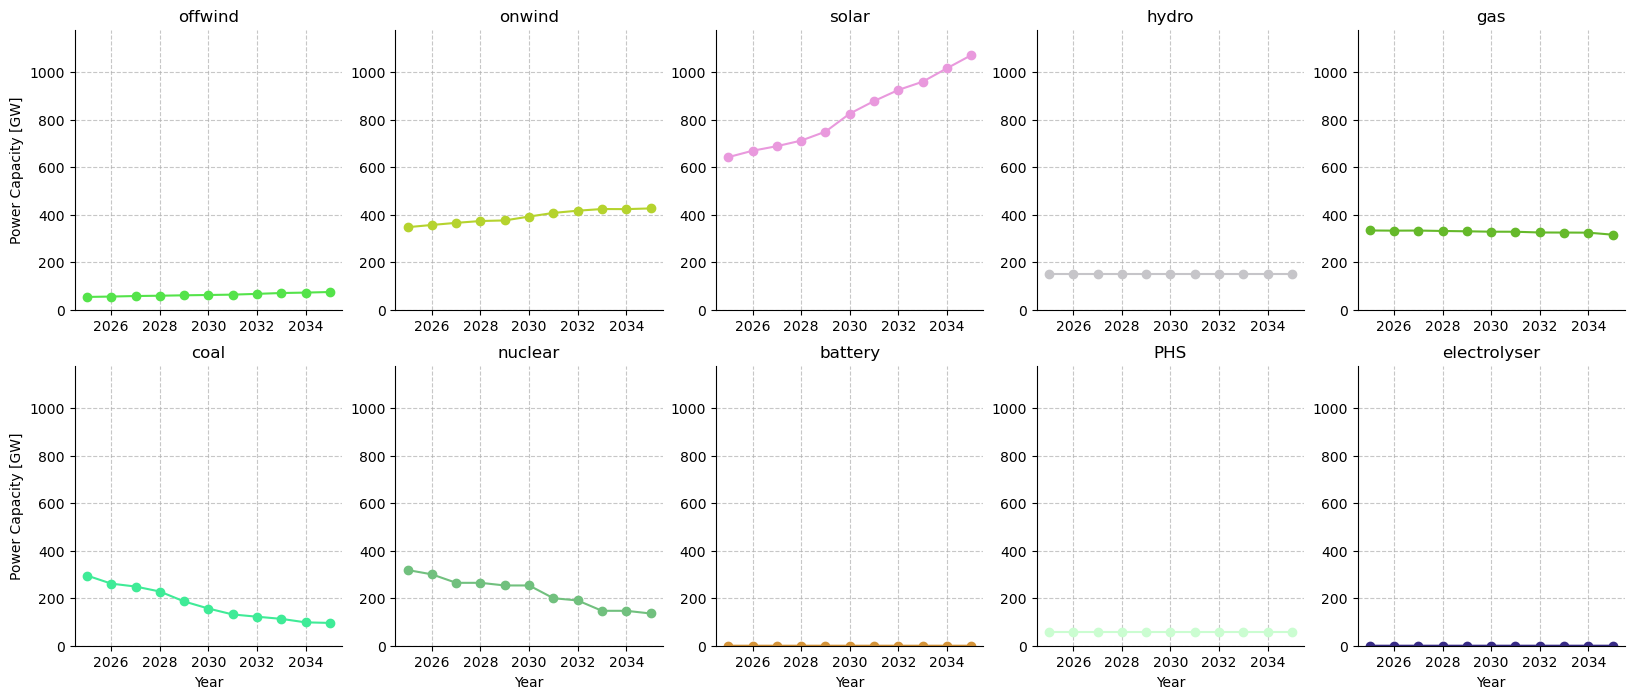

In [126]:
fig, axs = plt.subplots(2, len(capacities)//2, figsize=(len(capacities)//2 * 4, 8))

for i, (name, row) in enumerate(data.iterrows()):
    ax = axs.flatten()[i]
    row.plot(ax=ax, marker='o', color=np.random.rand(3,))
    ax.set_title(name)

for ax in axs.flatten():
    ax.set_ylim(0, data.max().max() * 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axs[1]:
    ax.set_xlabel('Year')

for ax in axs[:,0]:
    ax.set_ylabel('Power Capacity [GW]')

plt.show()

In [82]:
n.statistics.optimal_capacity().loc[idx[:, 'nuclear']]

component
Generator    105286.10000
Link         318877.60736
dtype: float64